In [1]:
import importlib.util
import sys
from datetime import date
import pandas as pd
import numpy as np
from typing import Dict, Literal, Optional
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.dates as mdates
import os
from pathlib import Path
from src.dataloading import EpiDataLoader
from src.dataloading.gnndataloader import GNNDataLoader

wissdaten_dir    = os.environ.get('TMPDIR') +'/wissdaten/'
data_env         = os.path.join(wissdaten_dir, 'ZKI-PH4/deschrijvers_wissdaten/data')

data_module      = module_path = data_env + "/__init__.py"
spec = importlib.util.spec_from_file_location("data", module_path)
module = importlib.util.module_from_spec(spec)
sys.modules["data"] = module
spec.loader.exec_module(module)

from data.visuals import *
colors_dict = {}
colors_dict['context']    = hexcodes['sky blue']
colors_dict['future']     = hexcodes['soft red']
colors_dict['predictions']= hexcodes['moss green']

n_epochs = 100
import random

/home/de-schrijvers/.conda/envs/gnenv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


/home/de-schrijvers/.conda/envs/gnenv/lib/python3.11/site-packages/geopandas/geodataframe.py:1968: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)


file not found
tensor([1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
        1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
        1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
        1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
        1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
        1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
        1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
        1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
        1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
        1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
        1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
        1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
        1., 1., 1., 1., 1

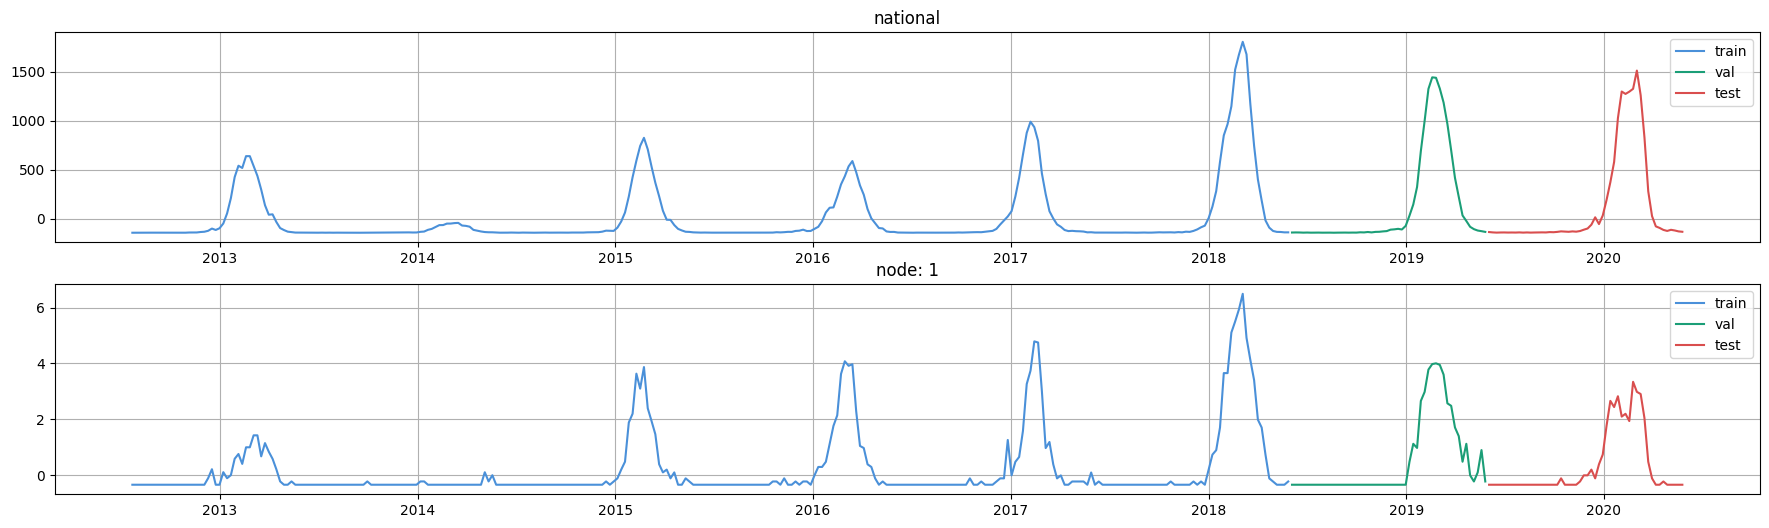

In [32]:
from src.models.temporal_gcn import TemporalGCNModel
from src.dataloading.gnndataloader import GNNDataLoader
from src.dataloading.graphconstructor import GraphConstructor
from src.dataloading.epidataloader import EpiDataLoader

n_periods = 8
n_epochs = 100

epidata = EpiDataLoader('influenza', data_env, aggr_level= '03', min_date='2012-06-01',max_date='2020-06-01')
epidata.add_time_features()
epidata.log_transform_target()
epidata.normalize('2018-06-01','2019-06-01','zscore')
epidata.add_lagged_features(range(1,8))
epidata.preview()


gnnloader1 = GNNDataLoader(epidata).retrieve_graph('identity_graph').construct_dataloaders(periods=n_periods)
gnnloader2 = GNNDataLoader(epidata).retrieve_graph('boolean_neighbors').construct_dataloaders(periods=n_periods)
gnnloader3 = GNNDataLoader(epidata).retrieve_graph('gravity_model_log').construct_dataloaders(periods=n_periods)
gnnloader4 = GNNDataLoader(epidata).retrieve_graph('gravity_model_top8_log').construct_dataloaders(periods=n_periods)

random_ids = [random.randint(0,399) for rr in range(10)]

Dataloader Snapshot: Data(x=[411, 10, 8], edge_index=[2, 411], y=[411], edge_weight=[411])
Epoch 1 train loss: 5.1814, val loss: 9.9269 ✓ (new best)
Epoch 2 train loss: 4.6259, val loss: 7.9334 ✓ (new best)
Epoch 3 train loss: 3.7010, val loss: 5.4569 ✓ (new best)
Epoch 4 train loss: 3.0361, val loss: 4.0430 ✓ (new best)
Epoch 5 train loss: 2.6452, val loss: 3.2865 ✓ (new best)
Epoch 6 train loss: 2.3979, val loss: 2.8205 ✓ (new best)
Epoch 7 train loss: 2.1852, val loss: 2.5105 ✓ (new best)
Epoch 8 train loss: 2.0315, val loss: 2.3037 ✓ (new best)
Epoch 9 train loss: 1.9213, val loss: 2.1691 ✓ (new best)
Epoch 10 train loss: 1.8408, val loss: 2.0529 ✓ (new best)
Epoch 11 train loss: 1.7699, val loss: 1.9773 ✓ (new best)
Epoch 12 train loss: 1.6832, val loss: 1.8877 ✓ (new best)
Epoch 13 train loss: 1.6425, val loss: 1.8281 ✓ (new best)
Epoch 14 train loss: 1.5897, val loss: 1.7979 ✓ (new best)
Epoch 15 train loss: 1.5737, val loss: 1.7770 ✓ (new best)
Epoch 16 train loss: 1.5333, val 

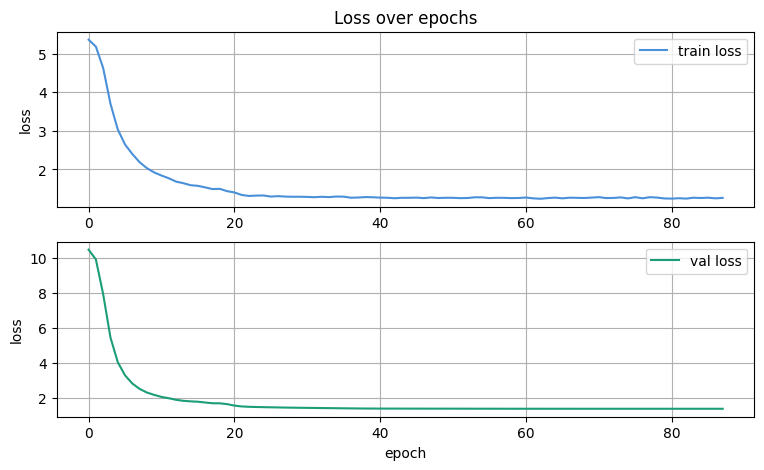

In [ ]:
# boolean neighbors
tGCN_idgraph = TemporalGCNModel(name = 'identity_graph', dataloader=gnnloader1)
tGCN_idgraph.set_model_hparams()
tGCN_idgraph.set_global_hparams(lr = 0.00005, n_epochs=n_epochs, scheduler_kwargs={'step_size':20}, min_delta = 0.001)
tGCN_idgraph.train()
tGCN_idgraph.forecast()

Dataloader Snapshot: Data(x=[411, 10, 8], edge_index=[2, 2529], y=[411], edge_weight=[2529])
Epoch 1 train loss: 5.1916, val loss: 9.7200 ✓ (new best)
Epoch 2 train loss: 4.5387, val loss: 7.2735 ✓ (new best)
Epoch 3 train loss: 3.5657, val loss: 4.7662 ✓ (new best)
Epoch 4 train loss: 3.0284, val loss: 3.6328 ✓ (new best)
Epoch 5 train loss: 2.7153, val loss: 3.0226 ✓ (new best)
Epoch 6 train loss: 2.4839, val loss: 2.6496 ✓ (new best)
Epoch 7 train loss: 2.2985, val loss: 2.4023 ✓ (new best)
Epoch 8 train loss: 2.1393, val loss: 2.2309 ✓ (new best)
Epoch 9 train loss: 2.0035, val loss: 2.0943 ✓ (new best)
Epoch 10 train loss: 1.9255, val loss: 1.9952 ✓ (new best)
Epoch 11 train loss: 1.8297, val loss: 1.9255 ✓ (new best)
Epoch 12 train loss: 1.7827, val loss: 1.8641 ✓ (new best)
Epoch 13 train loss: 1.7110, val loss: 1.8254 ✓ (new best)
Epoch 14 train loss: 1.6590, val loss: 1.7983 ✓ (new best)
Epoch 15 train loss: 1.6070, val loss: 1.7393 ✓ (new best)
Epoch 16 train loss: 1.6019, va

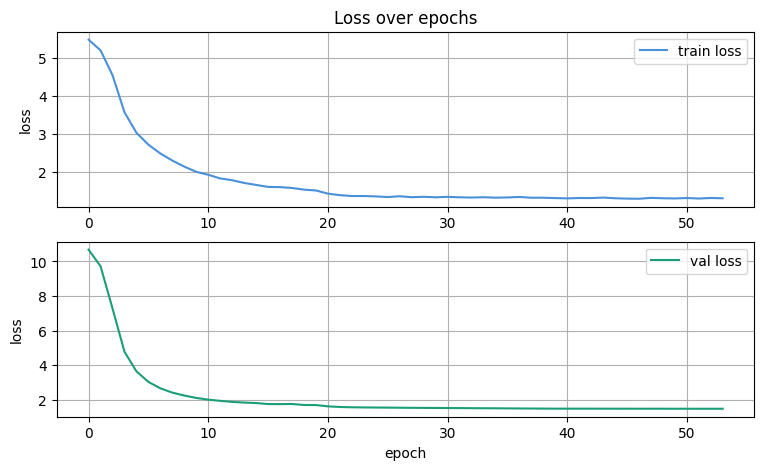

In [16]:
# boolean neighbors
tGCN_bngraph = TemporalGCNModel(name = 'boolean_neighbors', dataloader=gnnloader2)
tGCN_bngraph.set_model_hparams()
tGCN_bngraph.set_global_hparams(lr = 0.00005, n_epochs=n_epochs, scheduler_kwargs={'step_size':20}, min_delta = 0.01)
tGCN_bngraph.train()
tGCN_bngraph.forecast()

Dataloader Snapshot: Data(x=[411, 10, 8], edge_index=[2, 3695], y=[411], edge_weight=[3695])
Epoch 1 train loss: 4.8638, val loss: 8.6795 ✓ (new best)
Epoch 2 train loss: 3.9346, val loss: 5.6808 ✓ (new best)
Epoch 3 train loss: 3.0974, val loss: 3.9271 ✓ (new best)
Epoch 4 train loss: 2.6877, val loss: 3.1204 ✓ (new best)
Epoch 5 train loss: 2.4236, val loss: 2.6966 ✓ (new best)
Epoch 6 train loss: 2.2390, val loss: 2.4418 ✓ (new best)
Epoch 7 train loss: 2.1267, val loss: 2.2904 ✓ (new best)
Epoch 8 train loss: 2.0366, val loss: 2.1898 ✓ (new best)
Epoch 9 train loss: 1.9409, val loss: 2.1061 ✓ (new best)
Epoch 10 train loss: 1.8828, val loss: 2.0595 ✓ (new best)
Epoch 11 train loss: 1.8627, val loss: 2.0063 ✓ (new best)
Epoch 12 train loss: 1.8031, val loss: 1.9716 ✓ (new best)
Epoch 13 train loss: 1.7765, val loss: 1.9389 ✓ (new best)
Epoch 14 train loss: 1.7206, val loss: 1.8977 ✓ (new best)
Epoch 15 train loss: 1.7086, val loss: 1.8830 ✓ (new best)
Epoch 16 train loss: 1.6692, va

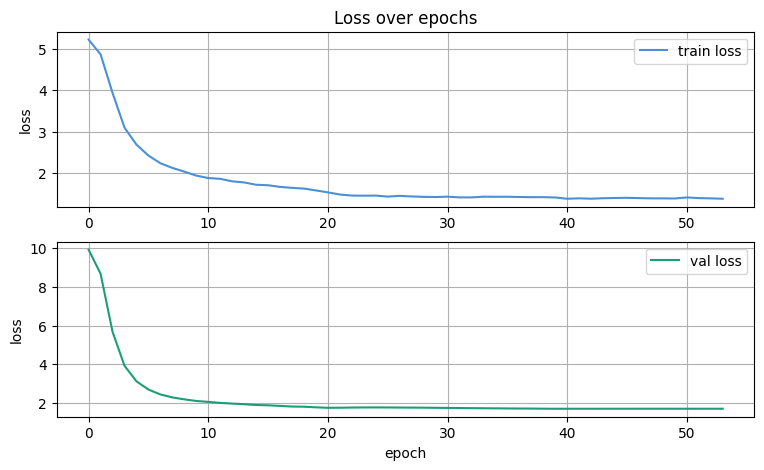

In [34]:
# boolean neighbors
tGCN_bngraph = TemporalGCNModel(name = 'gravity_model_log', dataloader=gnnloader4)
tGCN_bngraph.set_model_hparams()
tGCN_bngraph.set_global_hparams(lr = 0.00005, n_epochs=n_epochs, scheduler_kwargs={'step_size':20}, min_delta = 0.01)
tGCN_bngraph.train()
tGCN_bngraph.forecast()

Dataloader Snapshot: Data(x=[411, 10, 8], edge_index=[2, 4255], y=[411], edge_weight=[4255])
Epoch 1 train loss: 5.2517, val loss: 9.2538 ✓ (new best)
Epoch 2 train loss: 4.0363, val loss: 5.8244 ✓ (new best)
Epoch 3 train loss: 3.3192, val loss: 4.4930 ✓ (new best)
Epoch 4 train loss: 2.9441, val loss: 3.7074 ✓ (new best)
Epoch 5 train loss: 2.6963, val loss: 3.2081 ✓ (new best)
Epoch 6 train loss: 2.4765, val loss: 2.8471 ✓ (new best)
Epoch 7 train loss: 2.3065, val loss: 2.5740 ✓ (new best)
Epoch 8 train loss: 2.1489, val loss: 2.3835 ✓ (new best)
Epoch 9 train loss: 2.0550, val loss: 2.2313 ✓ (new best)
Epoch 10 train loss: 1.9682, val loss: 2.1526 ✓ (new best)
Epoch 11 train loss: 1.9171, val loss: 2.0429 ✓ (new best)
Epoch 12 train loss: 1.8300, val loss: 1.9796 ✓ (new best)
Epoch 13 train loss: 1.7931, val loss: 1.9548 ✓ (new best)
Epoch 14 train loss: 1.7482, val loss: 1.8968 ✓ (new best)
Epoch 15 train loss: 1.7040, val loss: 1.8806 ✓ (new best)
Epoch 16 train loss: 1.6767, va

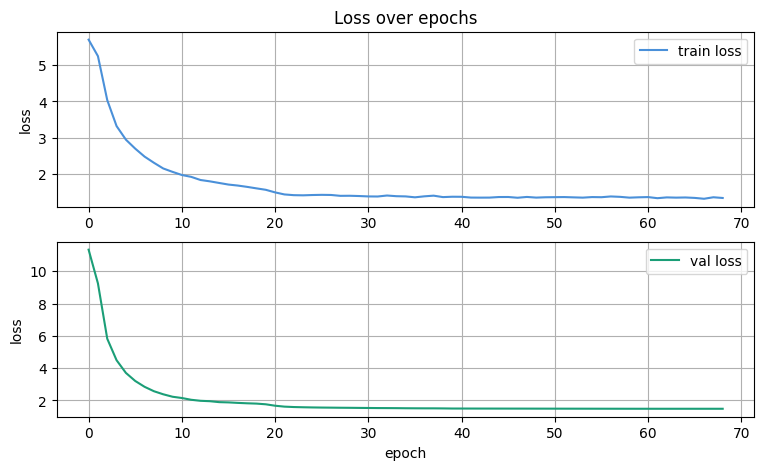

In [36]:
# boolean neighbors
tGCN_bngraph = TemporalGCNModel(name = 'gravity_model_top8_log', dataloader=gnnloader3)
tGCN_bngraph.set_model_hparams()
tGCN_bngraph.set_global_hparams(lr = 0.00005, n_epochs=n_epochs, scheduler_kwargs={'step_size':20}, min_delta = 0.01)
tGCN_bngraph.train()
tGCN_bngraph.forecast()

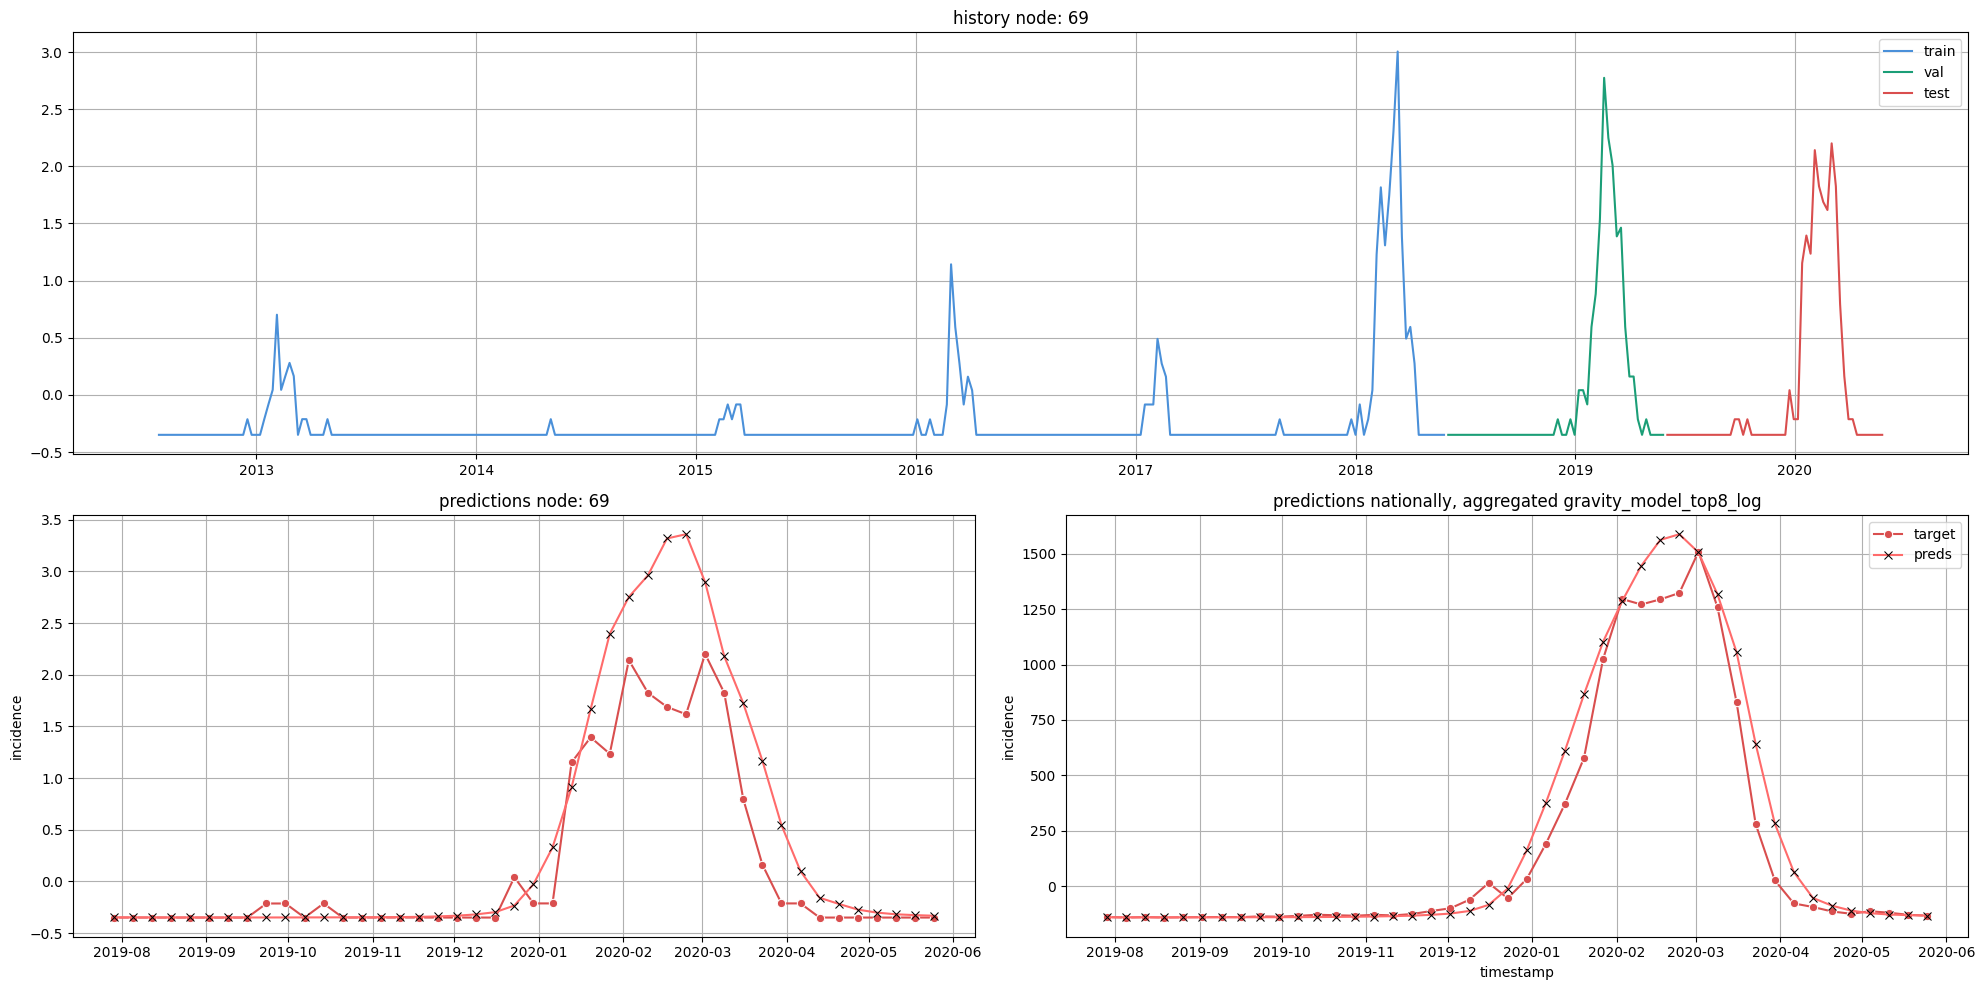

In [40]:
tGCN_bngraph.show_forecasts(69)

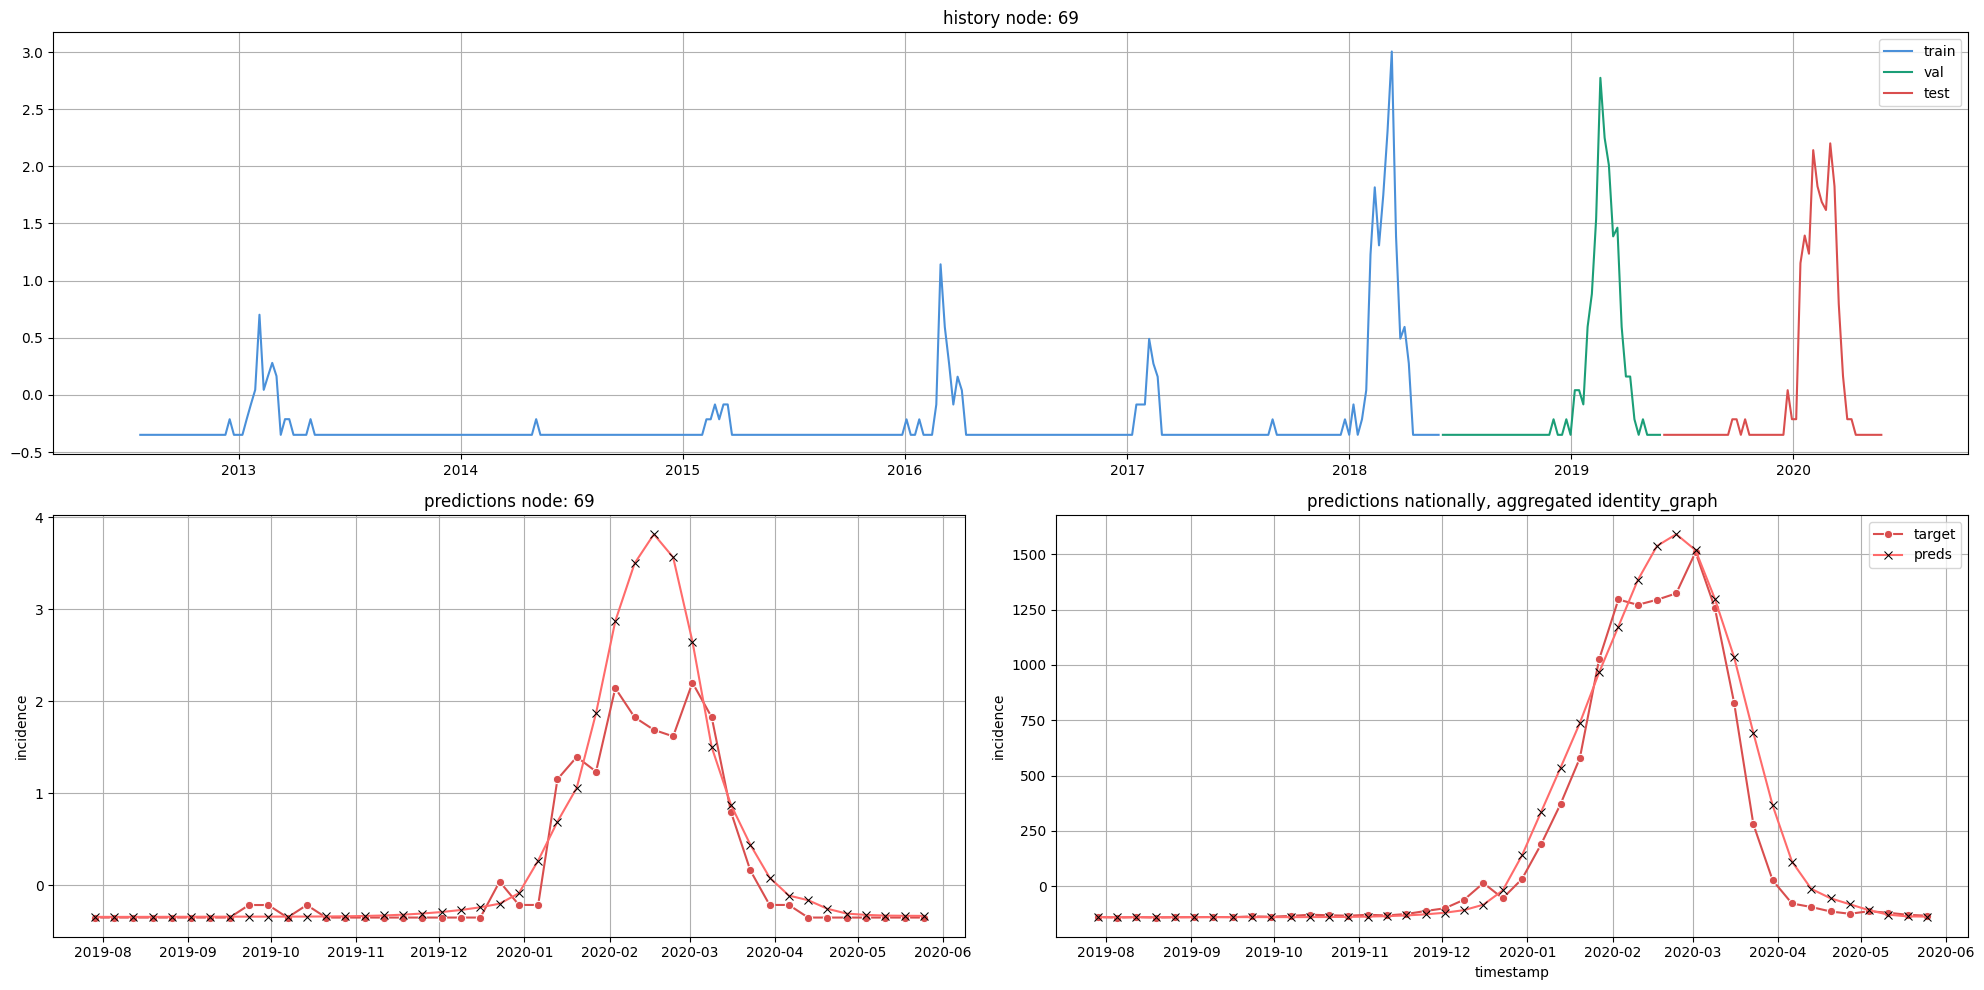

In [41]:
tGCN_idgraph.show_forecasts(69)